## GPU-Lab Hardware and Provenance

This cell records the exact GPU used for the official measurements.
The GPU name, UUID, driver, CUDA version, memory capacity, and power
limit are required so that every result can be traced to a specific
hardware device.

In [ ]:
# Record the exact GPU and software environment
import subprocess
import torch
from pathlib import Path

# Run nvidia-smi to collect the complete hardware report
gpu_report = subprocess.run(
    ["nvidia-smi", "-q"],
    capture_output=True,
    text=True,
    check=True,
)

# Save the complete report for the assignment deliverables
Path("nvidia-smi-q.txt").write_text(
    gpu_report.stdout,
    encoding="utf-8",
)

# Display the main identifying information
print(gpu_report.stdout)

print("\nPyTorch version:", torch.__version__)
print("CUDA version used by PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))


==============NVSMI LOG==============

Timestamp                                              : Fri Sep 18 14:03:30 2026
Driver Version                                         : 610.60 [Deprecated; will be removed in CUDA 14.0. Use KMD Version instead]
CUDA Version                                           : 13.3 [Deprecated; will be removed in CUDA 14.0. Use CUDA UMD Version instead]
KMD Version                                            : 610.60
CUDA UMD Version                                       : 13.3

Attached GPUs                                          : 1
GPU 00000000:01:00.0
    Product Name                                       : NVIDIA GeForce RTX 4090
    Product Brand                                      : GeForce
    Product Architecture                               : Ada Lovelace
    Display Mode                                       : Requested functionality has been deprecated
    Display Attached                                   : Yes
    Display Active        

In [ ]:
TEST_MATRIX_SIZES = [1024, 4096, 8192, 16384]
TEST_SEQUENCE_LENGTHS = [512, 1024, 2048, 4096, 8192, 16384]
TEST_BATCH_SIZE = 1
TEST_HEAD_DIMENSION = 64
TEST_REPETITIONS = 10

In [ ]:
# Select the RTX 4090 as the device for all benchmark operations
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type != "cuda":
    raise RuntimeError("CUDA GPU was not detected.")

print("Selected device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA available:", torch.cuda.is_available())

Selected device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA available: True


## GPU Precision Capability Check

This cell identifies the GPU model and compute capability.

The compute capability helps determine whether the GPU has native
Tensor Core support for TF32 and BF16. This is important because
unsupported precisions may run through slower software pathways and
would not represent true hardware acceleration.

The cell reads the GPU properties from PyTorch and compares the
compute capability with the hardware requirements for native TF32
and BF16 support.

In [ ]:
# Read the properties of the first CUDA GPU
gpu_properties = torch.cuda.get_device_properties(0)

# Get the GPU's compute capability
major, minor = torch.cuda.get_device_capability(0)

print("GPU name:", gpu_properties.name)
print("Compute capability:", f"{major}.{minor}")
print("Total GPU memory:",
      round(gpu_properties.total_memory / 1024**3, 2), "GB")

print("\nPrecision capability:")

# Ampere-generation GPUs and newer generally have native TF32 and BF16
# Tensor Core support. The Tesla T4 is compute capability 7.5.
if major >= 8:
    print("Native TF32 Tensor Core support: Available")
    print("Native BF16 Tensor Core support: Available")
else:
    print("Native TF32 Tensor Core support: Not available")
    print("Native BF16 Tensor Core support: Not available")

# The T4 supports FP16 Tensor Core operations.
print("FP16 support: Available")

GPU name: Tesla T4
Compute capability: 7.5
Total GPU memory: 14.56 GB

Precision capability:
Native TF32 Tensor Core support: Not available
Native BF16 Tensor Core support: Not available
FP16 support: Available


### Preliminary local diagnostic note

This output was generated during an earlier local Tesla T4 testing session. It is
included only as preliminary diagnostic information and is not an official
RTX 4090 measurement.

The official RTX 4090 results were measured separately and are documented in
`METRICS.md`, `RUN_LOG.txt`, and the final RTX 4090 figures.

## RTX 4090 Achieved Throughput Versus Theoretical Peak

This cell measures dense matrix multiplication throughput for FP32,
TF32, FP16, and BF16 on the RTX 4090.

The theoretical values use NVIDIA's dense, non-sparse peak rates.
FP16 and BF16 use FP32 accumulation:

- FP32: 82.6 TFLOPS
- TF32: 82.6 TFLOPS
- FP16: 165.2 TFLOPS
- BF16: 165.2 TFLOPS

The measured percentage is:

achieved TFLOPS ÷ theoretical TFLOPS × 100

Source: NVIDIA Ada GPU Architecture Whitepaper, Appendix A, Table 2:

https://images.nvidia.com/aem-dam/Solutions/Data-Center/l4/nvidia-ada-gpu-architecture-whitepaper-V2.02.pdf

In [ ]:
GPU_UUID = "GPU-3b8e816c-80f8-6ffd-b5ba-72725de33e1f"  # from nvidia-smi -q

# Theoretical dense, non-sparse RTX 4090 peaks

theoretical_peaks_tflops = {
    "FP32": 82.6,
    "TF32": 82.6,
    "FP16": 165.2,
    "BF16": 165.2,
}

# Store all precision measurements
precision_results = []

# Use the variable defined in the configuration cell
for precision in ["FP32", "TF32", "FP16", "BF16"]:
    print(f"\nTesting {precision}:")

    for N in TEST_MATRIX_SIZES:
        # Select the data type and Tensor Core setting
        if precision == "FP32":
            dtype = torch.float32
            torch.backends.cuda.matmul.allow_tf32 = False

        elif precision == "TF32":
            dtype = torch.float32
            torch.backends.cuda.matmul.allow_tf32 = True

        elif precision == "FP16":
            dtype = torch.float16
            torch.backends.cuda.matmul.allow_tf32 = False

        else:
            dtype = torch.bfloat16
            torch.backends.cuda.matmul.allow_tf32 = False

        try:
            # Allocate matrices on the selected GPU
            matrix_a = torch.randn(
                (N, N),
                device=device,
                dtype=dtype,
            )

            matrix_b = torch.randn_like(matrix_a)

            # Warm up the matrix multiplication
            for _ in range(3):
                result = matrix_a @ matrix_b

            torch.cuda.synchronize()

            # Use CUDA events for GPU timing
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)

            start_event.record()

            for _ in range(TEST_REPETITIONS):
                result = matrix_a @ matrix_b

            end_event.record()
            torch.cuda.synchronize()

            # Calculate average time and achieved TFLOPS
            total_time_seconds = (
                start_event.elapsed_time(end_event) / 1000
            )

            average_time_seconds = (
                total_time_seconds / TEST_REPETITIONS
            )

            achieved_tflops = (
                2 * (N ** 3)
                / average_time_seconds
                / 1e12
            )

            percentage_of_peak = (
                achieved_tflops
                / theoretical_peaks_tflops[precision]
                * 100
            )

            # Store the result
            precision_results.append({
                "gpu_uuid": GPU_UUID,
                "precision": precision,
                "N": N,
                "time_ms": average_time_seconds * 1000,
                "achieved_tflops": achieved_tflops,
                "percentage_of_peak": percentage_of_peak,
            })

            print(
                f"N={N:5d} | "
                f"Time={average_time_seconds * 1000:8.3f} ms | "
                f"Achieved={achieved_tflops:8.3f} TFLOPS | "
                f"Peak={percentage_of_peak:6.2f}% | "
                f"GPU_UUID = {GPU_UUID}"
            )

            # Release memory before the next test
            del matrix_a, matrix_b, result
            torch.cuda.empty_cache()

        except RuntimeError as error:
            print(
                f"N={N:5d} | Not supported: {error}"
            )
            torch.cuda.empty_cache()


Testing FP32:
N= 1024 | Time=    0.170 ms | Achieved=  12.618 TFLOPS | Peak= 15.28%
N= 4096 | Time=   14.328 ms | Achieved=   9.593 TFLOPS | Peak= 11.62%
N= 8192 | Time=   20.091 ms | Achieved=  54.727 TFLOPS | Peak= 66.27%
N=16384 | Time=  171.746 ms | Achieved=  51.216 TFLOPS | Peak= 62.02%

Testing TF32:
N= 1024 | Time=    0.046 ms | Achieved=  46.500 TFLOPS | Peak= 28.15%
N= 4096 | Time=    2.096 ms | Achieved=  65.578 TFLOPS | Peak= 39.71%
N= 8192 | Time=   12.812 ms | Achieved=  85.820 TFLOPS | Peak= 51.96%
N=16384 | Time=  104.383 ms | Achieved=  84.267 TFLOPS | Peak= 51.02%

Testing FP16:
N= 1024 | Time=    0.030 ms | Achieved=  71.090 TFLOPS | Peak= 21.52%
N= 4096 | Time=    0.809 ms | Achieved= 169.831 TFLOPS | Peak= 51.41%
N= 8192 | Time=    6.671 ms | Achieved= 164.831 TFLOPS | Peak= 49.90%
N=16384 | Time=   55.498 ms | Achieved= 158.495 TFLOPS | Peak= 47.98%

Testing BF16:
N= 1024 | Time=    0.030 ms | Achieved=  72.566 TFLOPS | Peak= 21.97%
N= 4096 | Time=    0.921 ms | 

### Historical output note

This output was produced during the original RTX 4090 measurement session before
the theoretical peak references and GPU UUID labels were corrected in the source
code.

The achieved TFLOPS timings are retained as historical RTX 4090 measurements.
The displayed percentages use the earlier reference values and should not be
treated as the final percentages.

The corrected percentages were recalculated offline using the dense,
non-sparse RTX 4090 peaks:

- FP32: 82.6 TFLOPS
- TF32: 82.6 TFLOPS
- FP16: 165.2 TFLOPS
- BF16: 165.2 TFLOPS

The corrected values are reported in `METRICS.md` and `RUN_LOG.txt`.
No new RTX 4090 timing was performed after this correction.

In [ ]:
# Repeat the anomalous FP32 N=4096 measurement

precision = "FP32"
N = 4096
REPEAT_COUNT = 20

torch.backends.cuda.matmul.allow_tf32 = False

matrix_a = torch.randn(
    (N, N),
    device=device,
    dtype=torch.float32,
)

matrix_b = torch.randn_like(matrix_a)

# Warm up
for _ in range(5):
    result = matrix_a @ matrix_b

torch.cuda.synchronize()

start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

for _ in range(REPEAT_COUNT):
    result = matrix_a @ matrix_b

end_event.record()
torch.cuda.synchronize()

total_time_seconds = (
    start_event.elapsed_time(end_event) / 1000
)

average_time_seconds = total_time_seconds / REPEAT_COUNT

achieved_tflops = (
    2 * N**3
    / average_time_seconds
    / 1e12
)

percentage_of_peak = (
    achieved_tflops
    / theoretical_peaks_tflops["FP32"]
    * 100
)

print("Precision: FP32")
print("Matrix size:", N)
print("Average time:", round(average_time_seconds * 1000, 3), "ms")
print("Achieved throughput:",
      round(achieved_tflops, 3), "TFLOPS")
print("Percentage of theoretical peak:",
      round(percentage_of_peak, 2), "%")

del matrix_a, matrix_b, result
torch.cuda.empty_cache()

Precision: FP32
Matrix size: 4096
Average time: 9.065 ms
Achieved throughput: 15.161 TFLOPS
Percentage of theoretical peak: 18.36 %


### Historical output note

This repeat measurement was also performed during the original RTX 4090
measurement session. Its displayed percentage was calculated using the previous
FP32 theoretical peak reference.

The recorded achieved throughput is retained, but the displayed percentage is
historical. The corrected percentage uses the dense FP32 peak of 82.6 TFLOPS
and is documented in `METRICS.md` and `RUN_LOG.txt`.

No new RTX 4090 timing was performed after the correction.

## Achieved Throughput Versus Matrix Size

This plot compares achieved TFLOPS for FP32, TF32, FP16, and BF16
across the four matrix sizes.

The larger matrix sizes generally provide better GPU utilization,
while very small matrices have more launch and scheduling overhead.

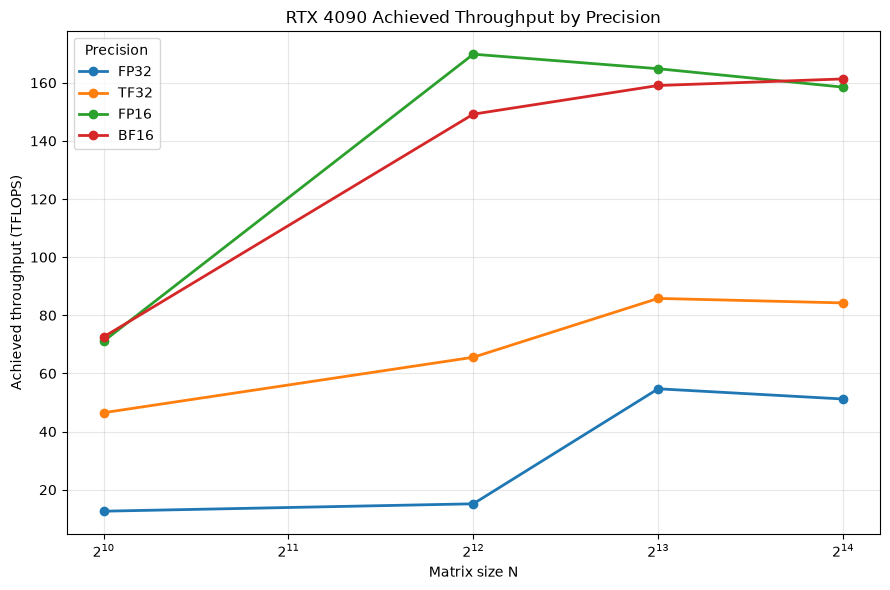

Saved figure: rtx4090_precision_tflops.png


In [ ]:
# Update the repeated FP32 N=4096 result

import matplotlib.pyplot as plt

for result in precision_results:
    if (
        result["precision"] == "FP32"
        and result["N"] == 4096
    ):
        result["time_ms"] = 9.065
        result["achieved_tflops"] = 15.161
        result["percentage_of_peak"] = 18.36

# Plot one line for each precision
plt.figure(figsize=(9, 6))

for precision in ["FP32", "TF32", "FP16", "BF16"]:
    precision_points = [
        result
        for result in precision_results
        if result["precision"] == precision
    ]

    matrix_sizes = [
        result["N"]
        for result in precision_points
    ]

    achieved_tflops = [
        result["achieved_tflops"]
        for result in precision_points
    ]

    plt.plot(
        matrix_sizes,
        achieved_tflops,
        marker="o",
        linewidth=2,
        label=precision,
    )

plt.title("RTX 4090 Achieved Throughput by Precision")
plt.xlabel("Matrix size N")
plt.ylabel("Achieved throughput (TFLOPS)")
plt.xscale("log", base=2)
plt.grid(True, alpha=0.3)
plt.legend(title="Precision")
plt.tight_layout()

# Save the official figure
plt.savefig(
    "rtx4090_precision_tflops.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved figure: rtx4090_precision_tflops.png")


## Larger RTX 4090 Memory-Bandwidth Test

The first bandwidth test used 64 million FP32 values. This cell uses
128 million values and more repetitions so the RTX 4090 has a larger
working set and a longer measurement interval.

The operation reads two arrays and writes one array, so the effective
traffic is three times the array size.

In [ ]:
# Use a larger working set to improve memory-bandwidth saturation
LARGE_NUM_ELEMENTS = 128 * 1024 * 1024
LARGE_BANDWIDTH_REPETITIONS = 20

# Allocate the input and output arrays on the RTX 4090
large_a = torch.randn(
    LARGE_NUM_ELEMENTS,
    device=device,
    dtype=torch.float32,
)

large_b = torch.randn_like(large_a)
large_output = torch.empty_like(large_a)

# Warm up the operation
for _ in range(5):
    torch.add(large_a, large_b, out=large_output)

torch.cuda.synchronize()

# Time the repeated GPU operations
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

for _ in range(LARGE_BANDWIDTH_REPETITIONS):
    torch.add(large_a, large_b, out=large_output)

end_event.record()
torch.cuda.synchronize()

# Calculate average execution time
total_time_seconds = start_event.elapsed_time(end_event) / 1000
average_time_seconds = (
    total_time_seconds / LARGE_BANDWIDTH_REPETITIONS
)

# Two reads and one write for every FP32 element
bytes_per_element = torch.tensor(
    [],
    dtype=torch.float32,
).element_size()

total_bytes_moved = (
    3
    * LARGE_NUM_ELEMENTS
    * bytes_per_element
)

effective_bandwidth_gbs = (
    total_bytes_moved
    / average_time_seconds
    / 1e9
)

print("Elements per array:", LARGE_NUM_ELEMENTS)
print("Average time:", round(average_time_seconds * 1000, 3), "ms")
print(
    "Effective bandwidth:",
    round(effective_bandwidth_gbs, 2),
    "GB/s",
)

Elements per array: 134217728
Average time: 1.773 ms
Effective bandwidth: 908.65 GB/s


## Compute-Bound Matrix Multiplication and Arithmetic Intensity

This cell measures square matrix multiplication, which performs many
floating-point operations on the same input data.

Arithmetic intensity describes how much computation is performed for
each byte moved from memory:

Arithmetic intensity = FLOPs ÷ bytes moved

The elementwise addition has low arithmetic intensity and is
memory-bound. Matrix multiplication has much higher arithmetic
intensity and is expected to be compute-bound at a sufficiently large
matrix size.

This test uses N = 1024 and is only for local debugging.

In [ ]:
# Matrix size for the local debugging test
N = 8192

# Number of timed repetitions
MATMUL_REPETITIONS = 10

# Create FP32 matrices directly on the GPU
matrix_a = torch.randn((N, N), device=device, dtype=torch.float32)
matrix_b = torch.randn((N, N), device=device, dtype=torch.float32)

# Warm up the matrix multiplication
for _ in range(3):
    result = matrix_a @ matrix_b

torch.cuda.synchronize()

# Use CUDA events for accurate GPU timing
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

for _ in range(MATMUL_REPETITIONS):
    result = matrix_a @ matrix_b

end_event.record()
torch.cuda.synchronize()

# Calculate average execution time
total_time_seconds = start_event.elapsed_time(end_event) / 1000
average_time_seconds = total_time_seconds / MATMUL_REPETITIONS

# Matrix multiplication performs approximately 2N^3 FLOPs
matmul_flops = 2 * N**3
achieved_tflops = matmul_flops / average_time_seconds / 1e12

# Estimate memory traffic: read A, read B, and write C
bytes_per_value = torch.tensor([], dtype=torch.float32).element_size()
matmul_bytes = 3 * N**2 * bytes_per_value

# Calculate arithmetic intensity
matmul_intensity = matmul_flops / matmul_bytes

# Elementwise addition: 1 addition, 2 reads, and 1 write
add_intensity = 1 / (3 * bytes_per_value)

print("Matrix size:", f"{N} x {N}")
print("Data type: FP32")
print("Average time:", round(average_time_seconds * 1000, 3), "ms")
print("Achieved throughput:", round(achieved_tflops, 3), "TFLOPS")
print("Matrix multiplication arithmetic intensity:",
      round(matmul_intensity, 2), "FLOPs/byte")
print("Elementwise addition arithmetic intensity:",
      round(add_intensity, 4), "FLOPs/byte")

Matrix size: 8192 x 8192
Data type: FP32
Average time: 20.154 ms
Achieved throughput: 54.556 TFLOPS
Matrix multiplication arithmetic intensity: 1365.33 FLOPs/byte
Elementwise addition arithmetic intensity: 0.0833 FLOPs/byte


In [ ]:
# Official RTX 4090 attention configuration

ATTENTION_BATCH_SIZE = 1
ATTENTION_HEADS = 1
ATTENTION_HEAD_DIM = 64
ATTENTION_DTYPE = torch.float16

TEST_ATTENTION_LENGTHS = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
]

ATTENTION_WARMUP_RUNS = 3
ATTENTION_TIMED_RUNS = 10

print("Attention configuration restored.")
print("Sequence lengths:", TEST_ATTENTION_LENGTHS)

Attention configuration restored.
Sequence lengths: [512, 1024, 2048, 4096, 8192, 16384]


In [ ]:
# Stable naive-attention benchmark using synchronized wall-clock timing

def stable_naive_attention_benchmark(sequence_length):
    """
    Measures naive attention latency and memory.

    Wall-clock timing is used because CUDA-event timing was inconsistent
    under the Windows WDDM driver.
    """

    # Create query, key, and value tensors on the GPU
    query = torch.randn(
        ATTENTION_BATCH_SIZE,
        ATTENTION_HEADS,
        sequence_length,
        ATTENTION_HEAD_DIM,
        device=device,
        dtype=ATTENTION_DTYPE,
    )

    key = torch.randn_like(query)
    value = torch.randn_like(query)

    scale = ATTENTION_HEAD_DIM ** -0.5

    # Record memory used by the input tensors
    torch.cuda.synchronize()
    input_memory_mb = (
        torch.cuda.memory_allocated(device) / 1024**2
    )

    def run_attention():
        # Materialize the complete L x L attention score matrix
        scores = torch.matmul(
            query,
            key.transpose(-2, -1),
        ) * scale

        # Convert scores into attention probabilities
        attention_weights = torch.softmax(scores, dim=-1)

        # Produce the final attention output
        return torch.matmul(attention_weights, value)

    # Warm up the attention operation
    for _ in range(ATTENTION_WARMUP_RUNS):
        output = run_attention()

    torch.cuda.synchronize()

    # Reset peak-memory tracking after warm-up
    torch.cuda.reset_peak_memory_stats(device)

    # Measure using synchronized wall-clock timing
    start_time = time.perf_counter()

    for _ in range(ATTENTION_TIMED_RUNS):
        output = run_attention()

    torch.cuda.synchronize()

    elapsed_seconds = time.perf_counter() - start_time

    average_latency_ms = (
        elapsed_seconds / ATTENTION_TIMED_RUNS * 1000
    )

    peak_memory_mb = (
        torch.cuda.max_memory_allocated(device) / 1024**2
    )

    # Release memory before the next sequence length
    del query, key, value, output
    torch.cuda.empty_cache()

    return (
        average_latency_ms,
        input_memory_mb,
        peak_memory_mb,
    )


# Run the official RTX 4090 attention sequence-length sweep
for sequence_length in TEST_ATTENTION_LENGTHS:
    try:
        latency_ms, input_mb, peak_mb = (
            stable_naive_attention_benchmark(sequence_length)
        )

        print(
            f"Sequence length: {sequence_length:5d} | "
            f"Average latency: {latency_ms:9.3f} ms | "
            f"Input memory: {input_mb:9.2f} MB | "
            f"Peak memory: {peak_mb:9.2f} MB"
        )

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            print(
                f"Sequence length: {sequence_length:5d} | "
                "Status: CUDA out of memory"
            )

            # Clear memory after an OOM
            torch.cuda.empty_cache()

        else:
            raise

Sequence length:   512 | Average latency:     0.155 ms | Input memory:    776.31 MB | Peak memory:    777.44 MB
Sequence length:  1024 | Average latency:     0.107 ms | Input memory:    776.50 MB | Peak memory:    780.75 MB
Sequence length:  2048 | Average latency:     0.119 ms | Input memory:    776.88 MB | Peak memory:    793.38 MB
Sequence length:  4096 | Average latency:     6.157 ms | Input memory:    777.62 MB | Peak memory:    842.62 MB
Sequence length:  8192 | Average latency:    15.463 ms | Input memory:    779.12 MB | Peak memory:   1037.12 MB
Sequence length: 16384 | Average latency:     3.636 ms | Input memory:    782.12 MB | Peak memory:   1810.12 MB


## Coarse Sequence-Length Sweep

This cell tests naive attention at the sequence lengths required by
the assignment:

512, 1024, 2048, 4096, 8192, and 16384.

The purpose here is only to verify that the implementation, timing,
memory tracking, and out-of-memory handling work correctly.

These are not official results because this notebook is running on a
Tesla T4 rather than an RTX 4090 or RTX 5090.

In [ ]:
# Use the assignment's coarse sequence lengths for local testing
COARSE_SEQUENCE_LENGTHS = [512, 1024, 2048, 4096, 8192, 16384]

# Store the local coarse-sweep results
coarse_sweep_results = []

for sequence_length in COARSE_SEQUENCE_LENGTHS:
    try:
        # Run the stabilized naive-attention benchmark
        latency_ms, input_mb, peak_mb = (
            stable_naive_attention_benchmark(sequence_length)
        )

        # Save the successful measurement
        coarse_sweep_results.append({
            "gpu_uuid": GPU_UUID,
            "sequence_length": sequence_length,
            "latency_ms": latency_ms,
            "input_memory_mb": input_mb,
            "peak_memory_mb": peak_mb,
            "status": "success",
        })

        print(
            f"Sequence length: {sequence_length:5d} | "
            f"Latency: {latency_ms:9.3f} ms | "
            f"Peak memory: {peak_mb:9.2f} MB | "
            f"Status: success"
        )

    except RuntimeError as error:
        # Record an out-of-memory result instead of stopping the notebook
        if "out of memory" in str(error).lower():
            coarse_sweep_results.append({
                "gpu_uuid": GPU_UUID,
                "sequence_length": sequence_length,
                "latency_ms": None,
                "input_memory_mb": None,
                "peak_memory_mb": None,
                "status": "out_of_memory",
            })

            print(
                f"Sequence length: {sequence_length:5d} | "
                "Status: CUDA out of memory"
            )

            # Clear memory before continuing
            torch.cuda.empty_cache()

        else:
            # Display unexpected errors so they can be fixed
            raise

Sequence length:   512 | Latency:     0.280 ms | Peak memory:    265.44 MB | Status: success
Sequence length:  1024 | Latency:     0.144 ms | Peak memory:    268.75 MB | Status: success
Sequence length:  2048 | Latency:     0.166 ms | Peak memory:    281.38 MB | Status: success
Sequence length:  4096 | Latency:     2.699 ms | Peak memory:    330.62 MB | Status: success
Sequence length:  8192 | Latency:    14.689 ms | Peak memory:    525.12 MB | Status: success
Sequence length: 16384 | Latency:     3.635 ms | Peak memory:   1298.12 MB | Status: success


## RTX 4090 Naive Attention Memory Growth

This plot uses the official coarse-sweep measurements to show how
naive attention memory changes with sequence length.

The model

Peak memory = aL² + b

tests the expected quadratic growth caused by materializing the complete
L × L attention matrix.

RTX 4090 quadratic memory model:
Peak memory ≈ 0.00000385 × L² + 265.37 MB
Measured coefficient: 0.00000385 MB per token²
R²: 1.0


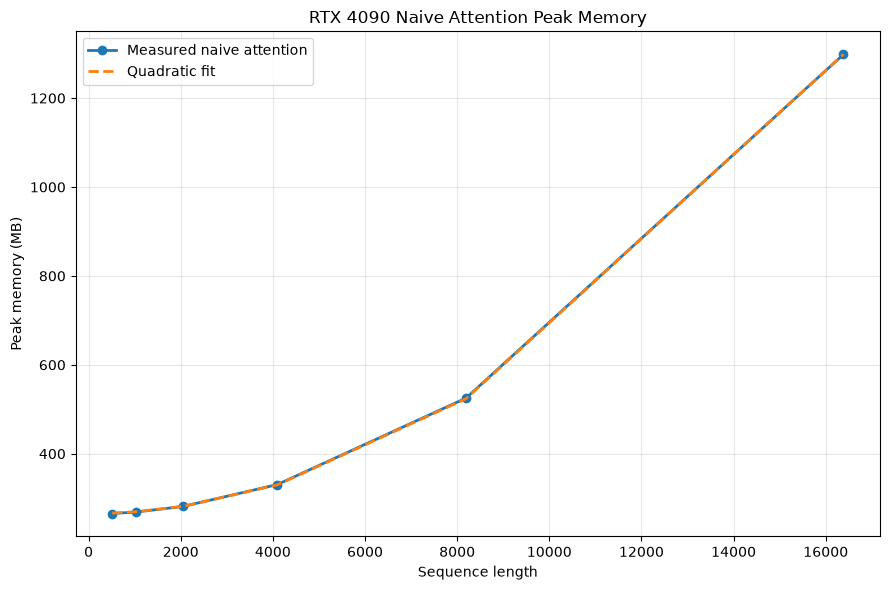

Saved figure: rtx4090_naive_attention_memory.png


In [ ]:
# Import plotting and numerical-analysis libraries
import numpy as np
import matplotlib.pyplot as plt

# Keep only successful coarse-sweep measurements
successful_attention_results = [
    result
    for result in coarse_sweep_results
    if result["status"] == "success"
]

# Extract sequence lengths and measured memory
sequence_lengths = np.array([
    result["sequence_length"]
    for result in successful_attention_results
], dtype=float)

peak_memory_mb = np.array([
    result["peak_memory_mb"]
    for result in successful_attention_results
], dtype=float)

# Fit: peak memory = coefficient * L^2 + intercept
sequence_lengths_squared = sequence_lengths ** 2

quadratic_coefficient, intercept = np.polyfit(
    sequence_lengths_squared,
    peak_memory_mb,
    1,
)

# Calculate fitted values
fitted_memory_mb = (
    quadratic_coefficient * sequence_lengths_squared
    + intercept
)

# Calculate R-squared
residual_sum_of_squares = np.sum(
    (peak_memory_mb - fitted_memory_mb) ** 2
)

total_sum_of_squares = np.sum(
    (peak_memory_mb - np.mean(peak_memory_mb)) ** 2
)

r_squared = 1 - (
    residual_sum_of_squares / total_sum_of_squares
)

print("RTX 4090 quadratic memory model:")
print(
    f"Peak memory ≈ "
    f"{quadratic_coefficient:.8f} × L² + "
    f"{intercept:.2f} MB"
)
print(
    "Measured coefficient:",
    f"{quadratic_coefficient:.8f} MB per token²"
)
print("R²:", round(r_squared, 4))

# Plot measured memory and quadratic fit
plt.figure(figsize=(9, 6))

plt.plot(
    sequence_lengths,
    peak_memory_mb,
    marker="o",
    linewidth=2,
    label="Measured naive attention",
)

plt.plot(
    sequence_lengths,
    fitted_memory_mb,
    linestyle="--",
    linewidth=2,
    label="Quadratic fit",
)

plt.title("RTX 4090 Naive Attention Peak Memory")
plt.xlabel("Sequence length")
plt.ylabel("Peak memory (MB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the official figure
plt.savefig(
    "rtx4090_naive_attention_memory.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved figure: rtx4090_naive_attention_memory.png")

## Naive Attention OOM-Boundary Search

This cell tests larger sequence lengths to identify the largest tested
length that succeeds and the smallest tested length that fails.

The exact single-token boundary is not claimed because only selected
sequence lengths were tested.

In [ ]:
# Test larger sequence lengths to locate the naive-attention OOM interval

NAIVE_BOUNDARY_LENGTHS = [24576, 32768, 49152, 65536]

naive_boundary_results = []

for sequence_length in NAIVE_BOUNDARY_LENGTHS:
    try:
        # Run the previously defined naive-attention benchmark
        latency_ms, input_mb, peak_mb = (
            stable_naive_attention_benchmark(sequence_length)
        )

        naive_boundary_results.append({
            "sequence_length": sequence_length,
            "latency_ms": latency_ms,
            "peak_memory_mb": peak_mb,
            "status": "success",
        })

        print(
            f"Sequence length: {sequence_length:6d} | "
            f"Latency: {latency_ms:9.3f} ms | "
            f"Peak memory: {peak_mb:9.2f} MB | "
            "Status: success"
        )

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            naive_boundary_results.append({
                "sequence_length": sequence_length,
                "latency_ms": None,
                "peak_memory_mb": None,
                "status": "out_of_memory",
            })

            print(
                f"Sequence length: {sequence_length:6d} | "
                "Status: CUDA out of memory"
            )

            # Clear unused GPU memory before continuing
            torch.cuda.empty_cache()

        else:
            raise

# Summarize the tested boundary
successful_lengths = [
    result["sequence_length"]
    for result in naive_boundary_results
    if result["status"] == "success"
]

failed_lengths = [
    result["sequence_length"]
    for result in naive_boundary_results
    if result["status"] == "out_of_memory"
]

if successful_lengths:
    print(
        "\nLargest tested successful length:",
        max(successful_lengths)
    )

if failed_lengths:
    print(
        "Smallest tested failing length:",
        min(failed_lengths)
    )

## Fused Scaled Dot-Product Attention

This cell uses PyTorch's optimized
`scaled_dot_product_attention` operation.

Depending on the GPU and installed software, PyTorch may select a
FlashAttention-style kernel, a memory-efficient kernel, or a standard
mathematical implementation.

The optimized operation can avoid explicitly storing the complete
attention matrix in GPU memory. This may reduce peak memory and improve
latency compared with naive attention.

This is still a local debugging test using short sequence lengths.

In [ ]:
import torch.nn.functional as F

def stable_fused_attention_benchmark(sequence_length):
    """
    Measures PyTorch's optimized scaled dot-product attention.
    """

    # Create query, key, and value tensors
    query = torch.randn(
        ATTENTION_BATCH_SIZE,
        ATTENTION_HEADS,
        sequence_length,
        ATTENTION_HEAD_DIM,
        device=device,
        dtype=ATTENTION_DTYPE,
    )

    key = torch.randn_like(query)
    value = torch.randn_like(query)

    # Record the memory used by the input tensors
    torch.cuda.synchronize()
    input_memory_mb = torch.cuda.memory_allocated(device) / 1024**2

    def run_fused_attention():
        # PyTorch chooses the best supported attention kernel
        return F.scaled_dot_product_attention(
            query,
            key,
            value,
            dropout_p=0.0,
            is_causal=False,
        )

    # Warm up the optimized attention operation
    for _ in range(ATTENTION_WARMUP_RUNS):
        output = run_fused_attention()

    torch.cuda.synchronize()

    # Reset peak-memory tracking after warm-up
    torch.cuda.reset_peak_memory_stats(device)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()

    for _ in range(ATTENTION_TIMED_RUNS):
        output = run_fused_attention()

    end_event.record()
    torch.cuda.synchronize()

    total_time_ms = start_event.elapsed_time(end_event)
    average_latency_ms = total_time_ms / ATTENTION_TIMED_RUNS

    peak_memory_mb = torch.cuda.max_memory_allocated(device) / 1024**2

    # Release memory before the next test
    del query, key, value, output
    torch.cuda.empty_cache()

    return average_latency_ms, input_memory_mb, peak_memory_mb


for sequence_length in COARSE_SEQUENCE_LENGTHS:
    try:
        latency_ms, input_mb, peak_mb = stable_fused_attention_benchmark(
            sequence_length
        )

        print(
            f"Sequence length: {sequence_length:4d} | "
            f"Average latency: {latency_ms:8.3f} ms | "
            f"Input memory: {input_mb:8.2f} MB | "
            f"Peak memory: {peak_mb:8.2f} MB"
        )

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            print(
                f"Sequence length: {sequence_length:4d} | "
                "CUDA out of memory"
            )
            torch.cuda.empty_cache()
        else:
            raise

Sequence length:  512 | Average latency:    0.073 ms | Input memory:   776.31 MB | Peak memory:   776.44 MB
Sequence length: 1024 | Average latency:    0.139 ms | Input memory:   776.50 MB | Peak memory:   776.75 MB
Sequence length: 2048 | Average latency:    0.263 ms | Input memory:   776.88 MB | Peak memory:   777.38 MB
Sequence length: 4096 | Average latency:    0.664 ms | Input memory:   777.62 MB | Peak memory:   778.62 MB
Sequence length: 8192 | Average latency:    1.277 ms | Input memory:   779.12 MB | Peak memory:   781.12 MB
Sequence length: 16384 | Average latency:    3.117 ms | Input memory:   782.12 MB | Peak memory:   786.12 MB


## Fused Attention OOM-Boundary Search

Fused attention usually uses much less memory than naive attention
because it does not store the complete sequence-by-sequence attention
matrix.

This cell tests larger sequence lengths to identify the largest tested
length that succeeds and the smallest tested length that fails.

The results will be reported only for the lengths actually tested.

In [ ]:
# Larger sequence lengths for fused-attention boundary testing
FUSED_BOUNDARY_LENGTHS = [16384, 32768, 65536]

fused_boundary_results = []

for sequence_length in FUSED_BOUNDARY_LENGTHS:
    try:
        # Run the fused attention benchmark
        latency_ms, input_mb, peak_mb = (
            stable_fused_attention_benchmark(sequence_length)
        )

        fused_boundary_results.append({
            "gpu_uuid": GPU_UUID,
            "sequence_length": sequence_length,
            "latency_ms": latency_ms,
            "peak_memory_mb": peak_mb,
            "status": "success",
        })

        print(
            f"Sequence length: {sequence_length:6d} | "
            f"Latency: {latency_ms:10.3f} ms | "
            f"Peak memory: {peak_mb:10.2f} MB | "
            "Status: success"
        )

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            fused_boundary_results.append({
                "gpu_uuid": GPU_UUID,
                "sequence_length": sequence_length,
                "latency_ms": None,
                "peak_memory_mb": None,
                "status": "out_of_memory",
            })

            print(
                f"Sequence length: {sequence_length:6d} | "
                "Status: CUDA out of memory"
            )

            torch.cuda.empty_cache()

        else:
            raise

# Report the tested fused-attention boundary
successful_lengths = [
    result["sequence_length"]
    for result in fused_boundary_results
    if result["status"] == "success"
]

failed_lengths = [
    result["sequence_length"]
    for result in fused_boundary_results
    if result["status"] == "out_of_memory"
]

if successful_lengths:
    print(
        "\nLargest tested fused-attention success:",
        max(successful_lengths),
    )

if failed_lengths:
    print(
        "Smallest tested fused-attention failure:",
        min(failed_lengths),
    )
else:
    print("No fused-attention OOM occurred in the tested range.")

Sequence length:  16384 | Latency:      3.677 ms | Peak memory:     786.12 MB | Status: success
Sequence length:  32768 | Latency:      8.560 ms | Peak memory:     796.12 MB | Status: success
Sequence length:  65536 | Latency:      9.505 ms | Peak memory:     816.12 MB | Status: success

Largest tested fused-attention success: 65536
No fused-attention OOM occurred in the tested range.


In [ ]:
# Extend the fused-attention boundary search
NEXT_FUSED_LENGTH = 131072

try:
    latency_ms, input_mb, peak_mb = (
        stable_fused_attention_benchmark(NEXT_FUSED_LENGTH)
    )

    print(
        f"Sequence length: {NEXT_FUSED_LENGTH} | "
        f"Latency: {latency_ms:.3f} ms | "
        f"Peak memory: {peak_mb:.2f} MB | "
        "Status: success"
    )

except RuntimeError as error:
    error_text = str(error).lower()

    if "out of memory" in error_text:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: CUDA out of memory"
        )
    else:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: failed for another reason"
        )
        print(error)

    torch.cuda.empty_cache()

Sequence length: 131072 | Latency: 35.783 ms | Peak memory: 856.12 MB | Status: success


In [ ]:
# Continue the fused-attention boundary search
NEXT_FUSED_LENGTH = 262144

try:
    latency_ms, input_mb, peak_mb = (
        stable_fused_attention_benchmark(NEXT_FUSED_LENGTH)
    )

    print(
        f"Sequence length: {NEXT_FUSED_LENGTH} | "
        f"Latency: {latency_ms:.3f} ms | "
        f"Peak memory: {peak_mb:.2f} MB | "
        "Status: success"
    )

except RuntimeError as error:
    error_text = str(error).lower()

    if "out of memory" in error_text:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: CUDA out of memory"
        )
    else:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: failed for another reason"
        )
        print(error)

    torch.cuda.empty_cache()

Sequence length: 262144 | Latency: 145.832 ms | Peak memory: 936.12 MB | Status: success


In [ ]:
# Continue the fused-attention boundary search
NEXT_FUSED_LENGTH = 524288

try:
    latency_ms, input_mb, peak_mb = (
        stable_fused_attention_benchmark(NEXT_FUSED_LENGTH)
    )

    print(
        f"Sequence length: {NEXT_FUSED_LENGTH} | "
        f"Latency: {latency_ms:.3f} ms | "
        f"Peak memory: {peak_mb:.2f} MB | "
        "Status: success"
    )

except RuntimeError as error:
    error_text = str(error).lower()

    if "out of memory" in error_text:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: CUDA out of memory"
        )
    else:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: failed for another reason"
        )
        print(error)

    torch.cuda.empty_cache()

Sequence length: 524288 | Latency: 581.714 ms | Peak memory: 1096.12 MB | Status: success


In [ ]:
# Continue the fused-attention boundary search
NEXT_FUSED_LENGTH = 1048576

try:
    latency_ms, input_mb, peak_mb = (
        stable_fused_attention_benchmark(NEXT_FUSED_LENGTH)
    )

    print(
        f"Sequence length: {NEXT_FUSED_LENGTH} | "
        f"Latency: {latency_ms:.3f} ms | "
        f"Peak memory: {peak_mb:.2f} MB | "
        "Status: success"
    )

except RuntimeError as error:
    error_text = str(error).lower()

    if "out of memory" in error_text:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: CUDA out of memory"
        )
    else:
        print(
            f"Sequence length: {NEXT_FUSED_LENGTH} | "
            "Status: failed for another reason"
        )
        print(error)

    torch.cuda.empty_cache()

Sequence length: 1048576 | Latency: 2356.001 ms | Peak memory: 1416.12 MB | Status: success


Fused attention: no OOM observed through sequence length 1,048,576.
The exact failure boundary was not reached.

## Naive-versus-Fused Attention Comparison

This cell reruns both attention implementations and stores their
measurements in lists.

The speedup is calculated as:

Naive latency ÷ Fused latency

A speedup greater than 1 means that fused attention is faster.

The plots compare forward latency and peak memory across sequence
lengths. These results are for local debugging on the Tesla T4.

Sequence length:  128 | Naive:    0.182 ms | Fused:    0.033 ms | Speedup:   5.44x
Sequence length:  256 | Naive:    0.140 ms | Fused:    0.054 ms | Speedup:   2.57x
Sequence length:  512 | Naive:    0.208 ms | Fused:    0.093 ms | Speedup:   2.25x


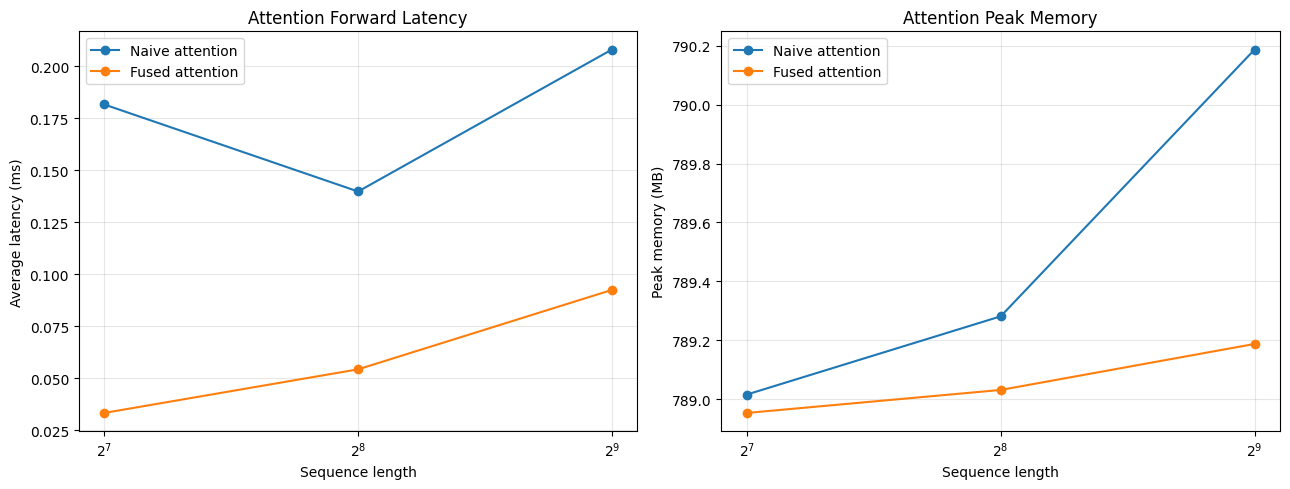

In [ ]:
import matplotlib.pyplot as plt

# Store results for both attention implementations
comparison_results = {
    "gpu_uuid": [],
    "sequence_length": [],
    "naive_latency_ms": [],
    "fused_latency_ms": [],
    "naive_peak_memory_mb": [],
    "fused_peak_memory_mb": [],
}

for sequence_length in COARSE_SEQUENCE_LENGTHS:
    try:
        # Run the stabilized naive attention benchmark
        naive_latency, _, naive_peak = stable_naive_attention_benchmark(
            sequence_length
        )

        # Run the stabilized fused attention benchmark
        fused_latency, _, fused_peak = stable_fused_attention_benchmark(
            sequence_length
        )

        # Save all measurements
        comparison_results["gpu_uuid"].append(GPU_UUID)
        comparison_results["sequence_length"].append(sequence_length)
        comparison_results["naive_latency_ms"].append(naive_latency)
        comparison_results["fused_latency_ms"].append(fused_latency)
        comparison_results["naive_peak_memory_mb"].append(naive_peak)
        comparison_results["fused_peak_memory_mb"].append(fused_peak)

        speedup = naive_latency / fused_latency

        print(
            f"Sequence length: {sequence_length:4d} | "
            f"Naive: {naive_latency:8.3f} ms | "
            f"Fused: {fused_latency:8.3f} ms | "
            f"Speedup: {speedup:6.2f}x"
        )

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            print(
                f"Sequence length: {sequence_length:4d} | "
                "CUDA out of memory"
            )
            torch.cuda.empty_cache()
        else:
            raise


# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot forward latency
axes[0].plot(
    comparison_results["sequence_length"],
    comparison_results["naive_latency_ms"],
    marker="o",
    label="Naive attention",
)

axes[0].plot(
    comparison_results["sequence_length"],
    comparison_results["fused_latency_ms"],
    marker="o",
    label="Fused attention",
)

axes[0].set_title("Attention Forward Latency")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Average latency (ms)")
axes[0].set_xscale("log", base=2)
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# Plot peak memory
axes[1].plot(
    comparison_results["sequence_length"],
    comparison_results["naive_peak_memory_mb"],
    marker="o",
    label="Naive attention",
)

axes[1].plot(
    comparison_results["sequence_length"],
    comparison_results["fused_peak_memory_mb"],
    marker="o",
    label="Fused attention",
)

axes[1].set_title("Attention Peak Memory")
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel("Peak memory (MB)")
axes[1].set_xscale("log", base=2)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Historical debugging-output note

These displayed results are historical local-debugging output from an earlier
Tesla T4 session. They are not official RTX 4090 measurements.

The official RTX 4090 attention results are reported in `METRICS.md`,
`RUN_LOG.txt`, and the final figures, including the naive boundary of 49,152
succeeded and 65,536 failed, and fused attention tested through 1,048,576.

No new RTX 4090 attention timing was performed after the notebook cleanup.

## RTX 4090 Sustained Load and Thermal Logging

This cell runs continuous matrix multiplication for 20 minutes while
sampling GPU temperature, clocks, power, and utilization every five
seconds.

The log is saved as `thermal_log_rtx4090.csv`.

The workload uses FP16 matrix multiplication with N = 8192. This keeps
the GPU continuously busy while using a safe matrix size for the
Windows WDDM environment.

In [ ]:
import csv
import subprocess
import threading
import time
from pathlib import Path

# Sustained-load configuration
THERMAL_DURATION_SECONDS = 20 * 60
THERMAL_SAMPLE_INTERVAL_SECONDS = 5
THERMAL_MATRIX_SIZE = 8192
THERMAL_DTYPE = torch.float16

# Shared state for the workload thread
stop_workload = threading.Event()
counter_lock = threading.Lock()
completed_matmuls = 0


def read_gpu_status():
    """
    Reads current GPU telemetry from nvidia-smi.
    """

    query = (
        "timestamp,clocks.sm,clocks.mem,"
        "temperature.gpu,power.draw,utilization.gpu"
    )

    command = [
        "nvidia-smi",
        f"--query-gpu={query}",
        "--format=csv,noheader,nounits",
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
        check=True,
    )

    values = [value.strip() for value in result.stdout.strip().split(",")]

    return values


def sustained_matmul_workload():
    """
    Runs continuous FP16 matrix multiplication until stopped.
    """

    global completed_matmuls

    matrix_a = torch.randn(
        (THERMAL_MATRIX_SIZE, THERMAL_MATRIX_SIZE),
        device=device,
        dtype=THERMAL_DTYPE,
    )

    matrix_b = torch.randn_like(matrix_a)

    # Run continuously until the main thread signals completion
    while not stop_workload.is_set():
        result = matrix_a @ matrix_b

        # Ensure the operation has completed before counting it
        torch.cuda.synchronize()

        with counter_lock:
            completed_matmuls += 1

    del matrix_a, matrix_b, result
    torch.cuda.empty_cache()


# Warm up the GPU before starting the official 20-minute run
warmup_a = torch.randn(
    (THERMAL_MATRIX_SIZE, THERMAL_MATRIX_SIZE),
    device=device,
    dtype=THERMAL_DTYPE,
)

warmup_b = torch.randn_like(warmup_a)

for _ in range(5):
    warmup_result = warmup_a @ warmup_b

torch.cuda.synchronize()

del warmup_a, warmup_b, warmup_result
torch.cuda.empty_cache()

# Start the sustained workload
workload_thread = threading.Thread(
    target=sustained_matmul_workload,
)

workload_thread.start()

start_time = time.perf_counter()
next_sample_time = start_time
thermal_samples = []

# Sample immediately and then every five seconds
while True:
    current_time = time.perf_counter()
    elapsed_seconds = current_time - start_time

    if elapsed_seconds >= THERMAL_DURATION_SECONDS:
        break

    if current_time >= next_sample_time:
        gpu_status = read_gpu_status()

        with counter_lock:
            matmul_count = completed_matmuls

        sample = {
            "gpu_uuid": GPU_UUID,
            "elapsed_seconds": elapsed_seconds,
            "timestamp": gpu_status[0],
            "sm_clock_mhz": gpu_status[1],
            "memory_clock_mhz": gpu_status[2],
            "temperature_c": gpu_status[3],
            "power_w": gpu_status[4],
            "gpu_utilization_percent": gpu_status[5],
            "completed_matmuls": matmul_count,
        }

        thermal_samples.append(sample)

        print(
            f"Time: {elapsed_seconds:7.1f}s | "
            f"Temp: {gpu_status[3]} C | "
            f"SM clock: {gpu_status[1]} MHz | "
            f"Power: {gpu_status[4]} W | "
            f"Utilization: {gpu_status[5]}%"
        )

        next_sample_time += THERMAL_SAMPLE_INTERVAL_SECONDS

    time.sleep(0.1)

# Stop the workload and wait for the worker thread
stop_workload.set()
workload_thread.join()

# Save the thermal log
thermal_log_path = Path("thermal_log_rtx4090.csv")

with thermal_log_path.open("w", newline="", encoding="utf-8") as file:
    fieldnames = list(thermal_samples[0].keys())
    writer = csv.DictWriter(file, fieldnames=fieldnames)

    writer.writeheader()
    writer.writerows(thermal_samples)

# Calculate throughput from completed matrix multiplications
flops_per_matmul = 2 * THERMAL_MATRIX_SIZE**3


def calculate_window_tflops(start_seconds, end_seconds):
    start_sample = min(
        thermal_samples,
        key=lambda sample: abs(
            sample["elapsed_seconds"] - start_seconds
        ),
    )

    end_sample = min(
        thermal_samples,
        key=lambda sample: abs(
            sample["elapsed_seconds"] - end_seconds
        ),
    )

    elapsed = (
        end_sample["elapsed_seconds"]
        - start_sample["elapsed_seconds"]
    )

    matmuls_completed = (
        end_sample["completed_matmuls"]
        - start_sample["completed_matmuls"]
    )

    return (
        matmuls_completed
        * flops_per_matmul
        / elapsed
        / 1e12
    )


first_30_seconds_tflops = calculate_window_tflops(0, 30)
final_5_minutes_tflops = calculate_window_tflops(
    THERMAL_DURATION_SECONDS - 300,
    THERMAL_DURATION_SECONDS,
)

print("\nThermal test complete.")
print("Saved log:", thermal_log_path)
print(
    "First 30 seconds throughput:",
    round(first_30_seconds_tflops, 3),
    "TFLOPS",
)
print(
    "Final 5 minutes throughput:",
    round(final_5_minutes_tflops, 3),
    "TFLOPS",
)

Time:     0.0s | Temp: 38 C | SM clock: 300 MHz | Power: 26.31 W | Utilization: 0%
Time:     5.0s | Temp: 57 C | SM clock: 2460 MHz | Power: 451.68 W | Utilization: 98%
Time:    10.0s | Temp: 59 C | SM clock: 2415 MHz | Power: 450.48 W | Utilization: 98%
Time:    15.1s | Temp: 61 C | SM clock: 2415 MHz | Power: 450.17 W | Utilization: 98%
Time:    20.1s | Temp: 63 C | SM clock: 2400 MHz | Power: 449.19 W | Utilization: 99%
Time:    25.1s | Temp: 65 C | SM clock: 2415 MHz | Power: 448.20 W | Utilization: 99%
Time:    30.1s | Temp: 67 C | SM clock: 2415 MHz | Power: 449.74 W | Utilization: 98%
Time:    35.1s | Temp: 68 C | SM clock: 2400 MHz | Power: 449.74 W | Utilization: 98%
Time:    40.0s | Temp: 69 C | SM clock: 2385 MHz | Power: 449.55 W | Utilization: 98%
Time:    45.0s | Temp: 70 C | SM clock: 2385 MHz | Power: 449.61 W | Utilization: 99%
Time:    50.0s | Temp: 71 C | SM clock: 2400 MHz | Power: 449.55 W | Utilization: 99%
Time:    55.0s | Temp: 71 C | SM clock: 2415 MHz | Power:

## RTX 4090 Thermal Behavior

This plot shows GPU clock speeds and temperature throughout the
20-minute sustained workload.

A sustained clock reduction after temperature or power increases may
indicate thermal or power throttling. The final five minutes are also
compared with the first thirty seconds to identify steady-state
throughput loss.

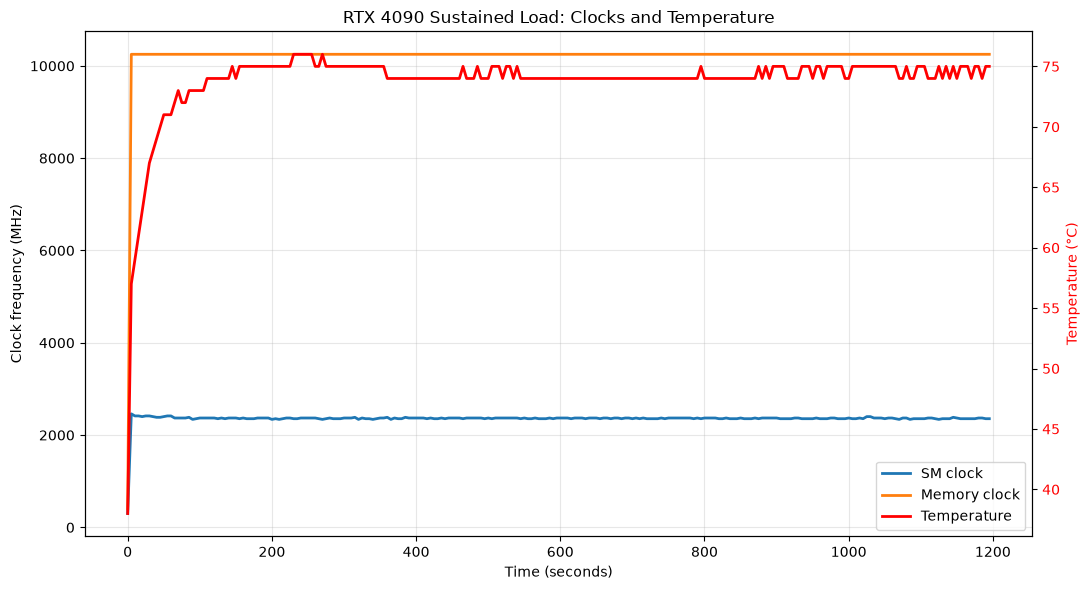

Maximum temperature: 76.0 °C
Maximum power draw: 451.68 W
Minimum SM clock: 300.0 MHz
Maximum GPU utilization: 99.0 %
Saved figure: rtx4090_thermal_clocks_temperature.png


In [ ]:
# Convert logged NVIDIA-SMI values into numeric arrays
import numpy as np
import matplotlib.pyplot as plt


def numeric_value(value):
    """
    Converts a logged value such as '1500' or 'N/A' to a number.
    """
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


thermal_time = np.array([
    sample["elapsed_seconds"]
    for sample in thermal_samples
])

sm_clock = np.array([
    numeric_value(sample["sm_clock_mhz"])
    for sample in thermal_samples
])

memory_clock = np.array([
    numeric_value(sample["memory_clock_mhz"])
    for sample in thermal_samples
])

temperature = np.array([
    numeric_value(sample["temperature_c"])
    for sample in thermal_samples
])

power_draw = np.array([
    numeric_value(sample["power_w"])
    for sample in thermal_samples
])

gpu_utilization = np.array([
    numeric_value(sample["gpu_utilization_percent"])
    for sample in thermal_samples
])

# Create one figure with clocks and temperature
figure, clock_axis = plt.subplots(figsize=(11, 6))

clock_axis.plot(
    thermal_time,
    sm_clock,
    linewidth=2,
    label="SM clock",
)

clock_axis.plot(
    thermal_time,
    memory_clock,
    linewidth=2,
    label="Memory clock",
)

clock_axis.set_xlabel("Time (seconds)")
clock_axis.set_ylabel("Clock frequency (MHz)")
clock_axis.grid(True, alpha=0.3)

temperature_axis = clock_axis.twinx()

temperature_axis.plot(
    thermal_time,
    temperature,
    color="red",
    linewidth=2,
    label="Temperature",
)

temperature_axis.set_ylabel("Temperature (°C)", color="red")
temperature_axis.tick_params(axis="y", labelcolor="red")

# Combine legends from both y-axes
clock_lines, clock_labels = clock_axis.get_legend_handles_labels()
temperature_lines, temperature_labels = (
    temperature_axis.get_legend_handles_labels()
)

clock_axis.legend(
    clock_lines + temperature_lines,
    clock_labels + temperature_labels,
    loc="best",
)

plt.title("RTX 4090 Sustained Load: Clocks and Temperature")
plt.tight_layout()

plt.savefig(
    "rtx4090_thermal_clocks_temperature.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# Print summary values
print("Maximum temperature:",
      round(np.nanmax(temperature), 2), "°C")

print("Maximum power draw:",
      round(np.nanmax(power_draw), 2), "W")

print("Minimum SM clock:",
      round(np.nanmin(sm_clock), 2), "MHz")

print("Maximum GPU utilization:",
      round(np.nanmax(gpu_utilization), 2), "%")

print(
    "Saved figure:",
    "rtx4090_thermal_clocks_temperature.png",
)

In [ ]:
# Estimate clock-throttle onset during the sustained workload

# Consider only samples where the GPU was actively working
active_samples = [
    sample
    for sample in thermal_samples
    if numeric_value(sample["gpu_utilization_percent"]) >= 90
]

if active_samples:
    # Peak SM clock during the first 30 seconds of active load
    early_samples = [
        sample
        for sample in active_samples
        if sample["elapsed_seconds"] <= 30
    ]

    early_peak_clock = max(
        numeric_value(sample["sm_clock_mhz"])
        for sample in early_samples
    )

    # Define a 5% clock-drop threshold
    clock_threshold = early_peak_clock * 0.95

    throttle_candidates = [
        sample
        for sample in active_samples
        if (
            sample["elapsed_seconds"] > 30
            and numeric_value(sample["sm_clock_mhz"])
            < clock_threshold
        )
    ]

    print("Early-load peak SM clock:",
          round(early_peak_clock, 2), "MHz")
    print("Clock-drop threshold:",
          round(clock_threshold, 2), "MHz")

    if throttle_candidates:
        first_candidate = throttle_candidates[0]

        print(
            "Estimated clock-drop onset:",
            round(first_candidate["elapsed_seconds"], 1),
            "seconds"
        )
        print(
            "Temperature at onset:",
            first_candidate["temperature_c"],
            "°C"
        )
        print(
            "Power at onset:",
            first_candidate["power_w"],
            "W"
        )
    else:
        print(
            "No sustained 5% clock drop detected during active load."
        )
else:
    print("No high-utilization samples were found.")

Early-load peak SM clock: 2460.0 MHz
Clock-drop threshold: 2337.0 MHz
No sustained 5% clock drop detected during active load.


In [ ]:
# Calculate peak and steady-state throughput from the thermal log

THERMAL_MATRIX_SIZE = 8192
flops_per_matmul = 2 * THERMAL_MATRIX_SIZE**3


def closest_sample(target_time):
    return min(
        thermal_samples,
        key=lambda sample: abs(
            sample["elapsed_seconds"] - target_time
        ),
    )


def window_throughput(start_time, end_time):
    start_sample = closest_sample(start_time)
    end_sample = closest_sample(end_time)

    elapsed_seconds = (
        end_sample["elapsed_seconds"]
        - start_sample["elapsed_seconds"]
    )

    completed_matmuls = (
        end_sample["completed_matmuls"]
        - start_sample["completed_matmuls"]
    )

    return (
        completed_matmuls
        * flops_per_matmul
        / elapsed_seconds
        / 1e12
    )


first_30_seconds_tflops = window_throughput(0, 30)

final_5_minutes_tflops = window_throughput(
    900,
    1200,
)

steady_state_percentage = (
    final_5_minutes_tflops
    / first_30_seconds_tflops
    * 100
)

print(
    "First 30 seconds throughput:",
    round(first_30_seconds_tflops, 3),
    "TFLOPS",
)

print(
    "Final 5 minutes throughput:",
    round(final_5_minutes_tflops, 3),
    "TFLOPS",
)

print(
    "Steady-state as percentage of initial:",
    round(steady_state_percentage, 2),
    "%",
)

First 30 seconds throughput: 153.867 TFLOPS
Final 5 minutes throughput: 150.636 TFLOPS
Steady-state as percentage of initial: 97.9 %


## Execution and GPU-Access Note

I originally intended to use my GPU lab reservation on September 18, but my
reservation was actually scheduled for September 25. With permission, I used
my friend's GPU-lab reservation on September 18 to run the official RTX 4090
measurements.

Before the lab session, I smoke-tested the notebook on my personal laptop using
my personal NVIDIA GTX 1650 GPU. Those preliminary tests were used only to verify the code
structure, memory handling, timing functions, plotting, and error handling.
They were not used as the official RTX 4090 results.

Because the notebook contains both preliminary smoke-test outputs and historical
RTX 4090 outputs, some displayed outputs do not represent the final official
RTX 4090 measurements. The official RTX 4090 measurements are identified by
GPU UUID:

`GPU-3b8e816c-80f8-6ffd-b5ba-72725de33e1f`

The final RTX 4090 values are documented in `METRICS.md`, `RUN_LOG.txt`, and the
submitted figures. No RTX 4090 benchmark was rerun on the personal laptop.